In [8]:
from pathlib import Path
import pandas as pd

project_root = Path.cwd().parent    # if you're inside /notebooks
csv_file = project_root / "data" / "raw_data.csv"

df = pd.read_csv(csv_file)



In [9]:
print("\n--- Dataset Overview ---")
print(f"Shape of the Dataset (Rows, Columns): {df.shape}")
print("\nFirst 5 Rows:")
print(df.head())
print("\nColumn Information (Data Types and Non-Null Counts):")
df.info()


--- Dataset Overview ---
Shape of the Dataset (Rows, Columns): (460292, 25)

First 5 Rows:
    Country  Age  Gender Smoking_Status Second_Hand_Smoke  \
0    Russia   82    Male  Former Smoker               Yes   
1  Thailand   66  Female  Former Smoker                No   
2  Colombia   87    Male  Former Smoker                No   
3     Egypt   51  Female  Former Smoker                No   
4  DR Congo   43    Male  Former Smoker                No   

  Air_Pollution_Exposure Occupation_Exposure Rural_or_Urban  \
0                 Medium                  No          Urban   
1                   High                  No          Rural   
2                 Medium                  No          Urban   
3                    Low                 Yes          Rural   
4                   High                  No          Urban   

  Socioeconomic_Status Healthcare_Access  ... Treatment_Access  \
0                 High           Limited  ...          Partial   
1               Middle        

In [10]:
# --- Check for Missing Values ---
print("\n--- Missing Values Check ---")
missing_values = df.isnull().sum()
print(missing_values[missing_values > 0]) # Only print columns with missing data

if missing_values.sum() == 0:
    print("No missing values found in the dataset.")
    
# --- Check for Duplicates ---
print("\n--- Duplicates Check ---")
duplicate_rows = df.duplicated().sum()
print(f"Number of Duplicate Rows: {duplicate_rows}")

# Note: If duplicates are found, you can remove them here:
# df.drop_duplicates(inplace=True)
# print("Duplicate rows removed.")


--- Missing Values Check ---
Mutation_Type       138173
Treatment_Access     46053
dtype: int64

--- Duplicates Check ---
Number of Duplicate Rows: 0


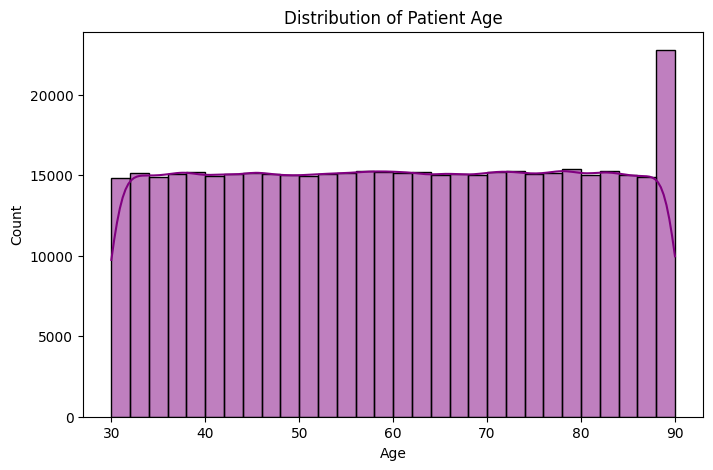

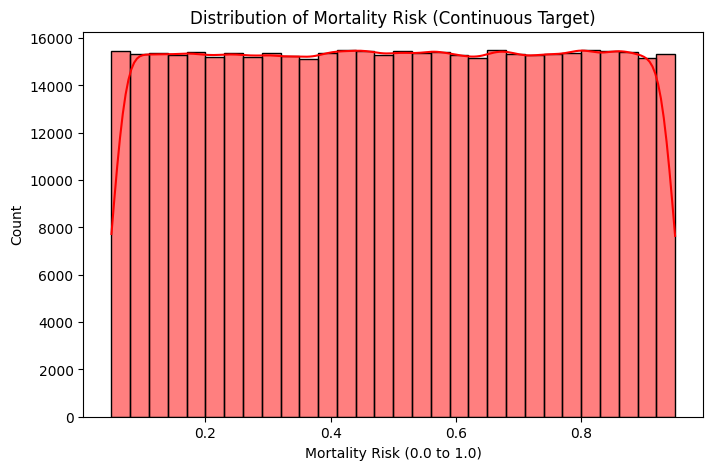


--- Categorical Feature Balance Check ---

Value Counts for Gender:
Gender
Male      230410
Female    229882
Name: count, dtype: int64

Value Counts for Smoking_Status:
Smoking_Status
Smoker           153754
Non-Smoker       153541
Former Smoker    152997
Name: count, dtype: int64

Value Counts for Final_Prediction:
Final_Prediction
No     368107
Yes     92185
Name: count, dtype: int64


C:\Users\user\AppData\Local\Temp\ipykernel_7992\992986889.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, palette='viridis')


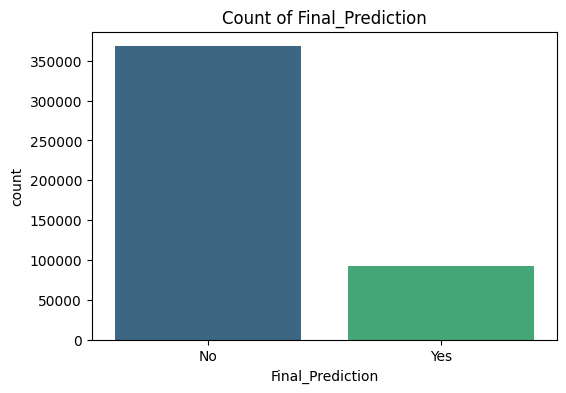

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- Distribution of Age ---
plt.figure(figsize=(8, 5))
sns.histplot(df['Age'], bins=30, kde=True, color='purple')
plt.title('Distribution of Patient Age')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

# --- Distribution of Continuous Target (Mortality_Risk) ---
plt.figure(figsize=(8, 5))
sns.histplot(df['Mortality_Risk'], bins=30, kde=True, color='red')
plt.title('Distribution of Mortality Risk (Continuous Target)')
plt.xlabel('Mortality Risk (0.0 to 1.0)')
plt.ylabel('Count')
plt.show()

# --- Value Counts for Categorical Features ---
print("\n--- Categorical Feature Balance Check ---")
for col in ['Gender', 'Smoking_Status', 'Final_Prediction']:
    print(f"\nValue Counts for {col}:")
    print(df[col].value_counts())
    
    # Visualize the balance of the Classification Target
    if col == 'Final_Prediction':
        plt.figure(figsize=(6, 4))
        sns.countplot(x=col, data=df, palette='viridis')
        plt.title(f'Count of {col}')
        plt.show()

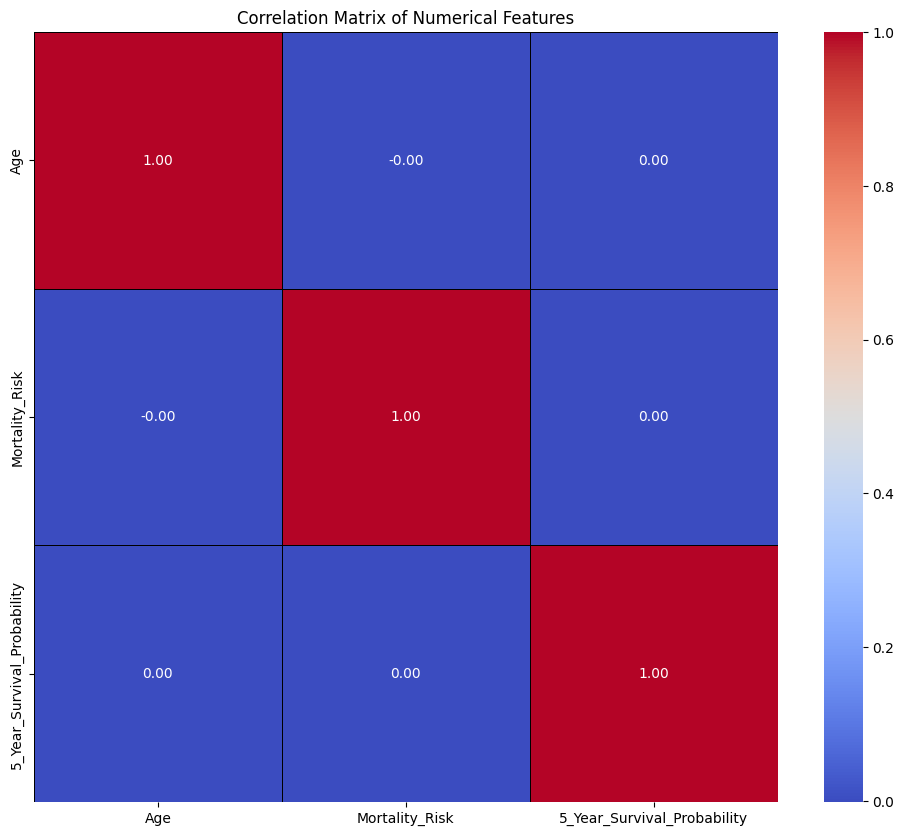

In [12]:
import numpy as np
# Select only numerical columns for the correlation matrix
numerical_cols = df.select_dtypes(include=np.number).columns
correlation_matrix = df[numerical_cols].corr()

plt.figure(figsize=(12, 10))
# Plot the heatmap
sns.heatmap(correlation_matrix, 
            annot=True,          # Show correlation values on the plot
            cmap='coolwarm',     # Color map (e.g., coolwarm, viridis)
            fmt=".2f",           # Format to 2 decimal places
            linewidths=.5,
            linecolor='black')
plt.title('Correlation Matrix of Numerical Features')
plt.show()

C:\Users\user\AppData\Local\Temp\ipykernel_7992\4182043139.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Smoking_Status', y='Mortality_Risk', data=df, palette='Set3')


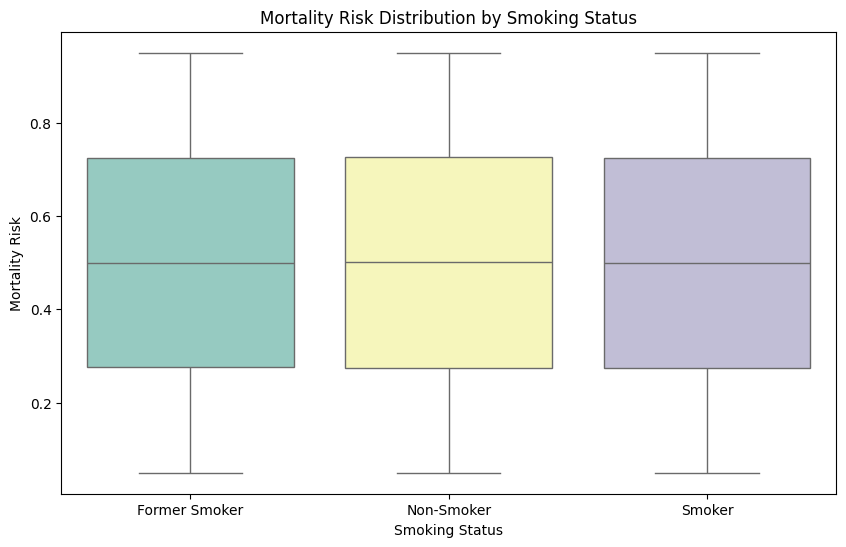

In [13]:
# Use a box plot to see how Mortality_Risk varies across categories
plt.figure(figsize=(10, 6))
sns.boxplot(x='Smoking_Status', y='Mortality_Risk', data=df, palette='Set3')
plt.title('Mortality Risk Distribution by Smoking Status')
plt.xlabel('Smoking Status')
plt.ylabel('Mortality Risk')
plt.show()

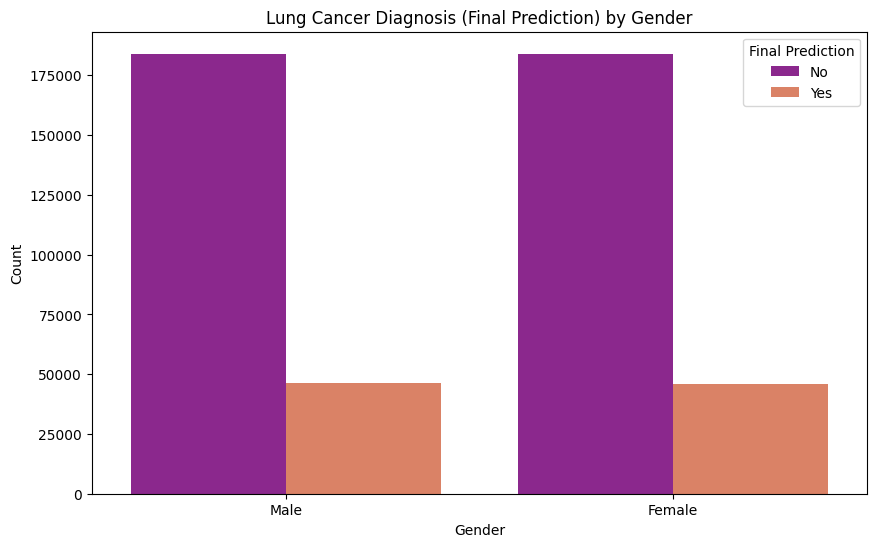

In [14]:
# Use a count plot with 'hue' to compare the diagnosis across categories
plt.figure(figsize=(10, 6))
sns.countplot(x='Gender', hue='Final_Prediction', data=df, palette='plasma')
plt.title('Lung Cancer Diagnosis (Final Prediction) by Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.legend(title='Final Prediction')
plt.show()